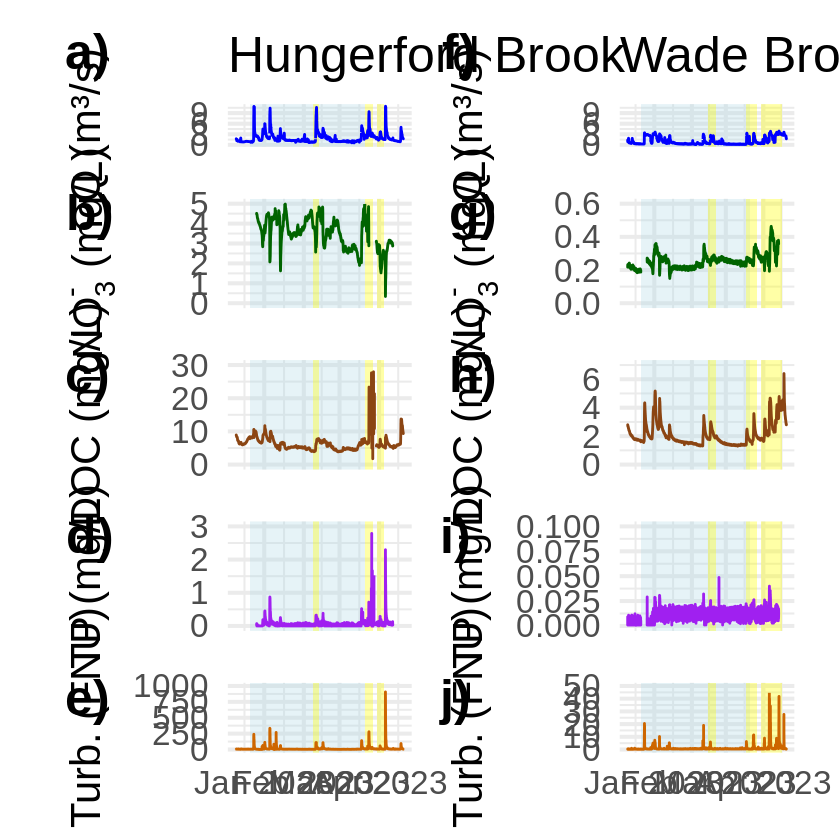

In [11]:
library(fs)
library(ggplot2)

# Set directories
home_dir <- Sys.getenv("HOME")
repo_dir <- file.path(home_dir, "OneDrive/git-repos/LCBP-interannual-EMMAs")
source(file.path(repo_dir, "Functions/plot_compare_stream_sensors.R")) 
data_dir <- file.path(repo_dir, "Data/")

# Define plotting range
timeseries_range <- as.POSIXct(c("2022-12-10", "2023-04-20"), tz = "UTC")

# Define Sampling Windows
hford_sampling_windows <- data.frame(
  start = as.POSIXct(c("2023-02-08 00:00", "2023-03-21 00:00", "2023-03-30 00:00"), tz = "UTC"),
  end   = as.POSIXct(c("2023-02-12 23:59", "2023-03-26 23:59", "2023-04-04 23:59"), tz = "UTC")
)

wade_sampling_windows <- data.frame(
  start = as.POSIXct(c("2023-02-14 00:00", "2023-03-18 00:00", "2023-03-30 00:00"), tz = "UTC"),
  end   = as.POSIXct(c("2023-02-20 23:59", "2023-03-26 23:59", "2023-04-15 23:59"), tz = "UTC")
)

# Run Function for Hungerford and Wade
combo_sensors <- plot_compare_stream_sensors(
  plot_range = timeseries_range,
  
  # Hungerford Variables
  site1_name       = "Hungerford",
  site1_samp_dates = hford_sampling_windows,
  s1_q_file        = file.path(data_dir, "StreamSensor_data", "hb_q_chem_20211001-20230930.csv"),
  s1_no3_file      = file.path(data_dir, "StreamSensor_data", "hb_q_chem_20211001-20230930.csv"),
  s1_doc_file      = file.path(data_dir, "StreamSensor_data", "DOC.DOC@Hungerford_Brook.20221001.csv"),
  s1_tp_file       = file.path(data_dir, "StreamSensor_data", "hb_q_chem_20211001-20230930.csv"),
  s1_turb_file     = file.path(data_dir, "StreamSensor_data", "Turbidity,_Form_Neph.Turbidity@Hungerford_Brook.20221001.csv"),
  
  # Wade Variables 
  site2_name       = "Wade",
  site2_samp_dates = wade_sampling_windows,
  s2_q_file        = file.path(data_dir, "StreamSensor_data", "wb_q_chem_20211001-20230930.csv"),
  s2_no3_file      = file.path(data_dir, "StreamSensor_data", "wb_q_chem_20211001-20230930.csv"),
  s2_doc_file      = file.path(data_dir, "StreamSensor_data", "DOC.DOC@Wade_Brook.20221001.csv"),
  s2_tp_file       = file.path(data_dir, "StreamSensor_data", "wb_q_chem_20211001-20230930.csv"),
  s2_turb_file     = file.path(data_dir, "StreamSensor_data", "Turbidity,_Form_Neph.Turbidity@Wade_Brook.20221001.csv"),
  
  # Limits 
  q_lim          = c(0, 11),
  s1_no3_lim     = c(0, 5),   # Hungerford Nitrate limit
  s2_no3_lim     = c(0, 0.6),   # Wade Nitrate limit 
  s1_doc_lim     = c(0, 30),
  s2_doc_lim     = c(0, 7),
  s1_tp_lim      = c(0, 3),   # Hungerford TP limit
  s2_tp_lim      = c(0, 0.1), # Wade TP limit 
  s1_turb_lim    = c(0, 1000),
  s2_turb_lim    = c(0, 50),
  base_font_size = 25
)

print(combo_sensors)
ggsave(file.path(repo_dir, "Output/Hydrographs/Sites_Comparison_2023_stream_sensor_timeseries.jpg"), 
       plot = combo_sensors, width = 18, height = 16, dpi = 300)